# Análisis exploratorio de los datos (EDA)


## 1. Introducción

El objetivo de este análisis exploratorio de datos (EDA) es estudiar las principales características del conjunto de datos de viviendas y analizar las relaciones existentes entre sus variables y el precio de la vivienda (`price`).

El análisis se realiza sobre el dataset obtenido tras el preprocesado inicial, documentado en el notebook `02_preprocessing`. En esta fase se estudiarán las distribuciones de las variables, las relaciones entre las características de las viviendas y el precio, las diferencias según localización y las principales relaciones entre variables.

Los resultados obtenidos permitirán identificar patrones relevantes, detectar posibles problemas que requieran un tratamiento adicional y establecer las decisiones necesarias para el preprocesado definitivo antes del modelado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Descripción general

En este apartado se realiza una descripción general del conjunto de datos obtenido tras el preprocesado inicial. Se comprueban sus dimensiones y tipos de variables y se resumen las principales características de las variables numéricas.

Estas comprobaciones tienen como objetivo conocer la estructura del dataset con el que se desarrollará el análisis exploratorio, sin repetir las comprobaciones de calidad realizadas previamente en la auditoría.

In [4]:
df = pd.read_csv("../data/processed/spanish_houses_preprocessed.csv")
print("Número de registros:", df.shape[0])
print("Número de variables:", df.shape[1])

Número de registros: 99816
Número de variables: 41


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99816 entries, 0 to 99815
Data columns (total 41 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ad_description                 95242 non-null  object 
 1   ad_last_update                 99816 non-null  object 
 2   air_conditioner                99816 non-null  int64  
 3   balcony                        99816 non-null  int64  
 4   bath_num                       99146 non-null  float64
 5   built_in_wardrobe              99816 non-null  int64  
 6   chimney                        99816 non-null  int64  
 7   condition                      85875 non-null  object 
 8   construct_date                 31875 non-null  float64
 9   energetic_certif               74507 non-null  object 
 10  floor                          79509 non-null  object 
 11  garage                         40627 non-null  object 
 12  garden                         99816 non-null 

In [7]:
df.dtypes.value_counts()

object     16
int64      14
float64    11
Name: count, dtype: int64

### Conclusiones

El dataset utilizado para el análisis exploratorio está compuesto por 99.816 registros y 41 variables. Tras el preprocesado inicial, las principales variables numéricas han sido convertidas a tipos adecuados, mientras que las variables categóricas y de texto se mantienen como variables de tipo `object` para su posterior análisis y transformación, cuando sea necesario.

A partir de esta estructura se procede al análisis univariante de las variables.

## 3. Análisis univariante

### 3.1. Variables numéricas

En primer lugar se analiza la distribución de las principales variables numéricas del conjunto de datos. Se estudian sus estadísticos descriptivos y representaciones gráficas con el objetivo de identificar las características generales de los datos, posibles asimetrías y valores extremos.

El análisis se centra en las variables cuantitativas con mayor relevancia para la caracterización de las viviendas y para el posterior modelado del precio.


In [11]:
# Identificamos las varibles numéricas

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Variables numéricas:")
print(list(numeric_cols))

Variables numéricas:
['air_conditioner', 'balcony', 'bath_num', 'built_in_wardrobe', 'chimney', 'construct_date', 'garden', 'ground_size', 'house_id', 'kitchen', 'lift', 'm2_real', 'm2_useful', 'price', 'reduced_mobility', 'room_num', 'storage_room', 'swimming_pool', 'terrace', 'unfurnished', 'number_of_companies_prov', 'population_prov', 'companies_prov_vs_national_%', 'population_prov_vs_national_%', 'renta_media_prov']


In [12]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
air_conditioner,99816.0,2.299231e-01,4.207852e-01,0.00,0.00,0.00,0.00,1.00
balcony,99816.0,1.818145e-01,3.856935e-01,0.00,0.00,0.00,0.00,1.00
bath_num,99146.0,1.988018e+00,1.221769e+00,1.00,1.00,2.00,2.00,84.00
built_in_wardrobe,99816.0,4.245011e-01,4.942695e-01,0.00,0.00,0.00,1.00,1.00
chimney,99816.0,3.691793e-02,1.885613e-01,0.00,0.00,0.00,0.00,1.00
construct_date,31875.0,1.982133e+03,9.604420e+01,1700.00,1970.00,1990.00,2005.00,9999.00
garden,99816.0,2.787629e-01,4.483929e-01,0.00,0.00,0.00,1.00,1.00
ground_size,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
house_id,99816.0,6.426140e+07,2.534249e+07,153995.00,38345365.00,82379308.00,84161765.75,85073788.00
kitchen,2029.0,1.000000e+00,0.000000e+00,1.00,1.00,1.00,1.00,1.00


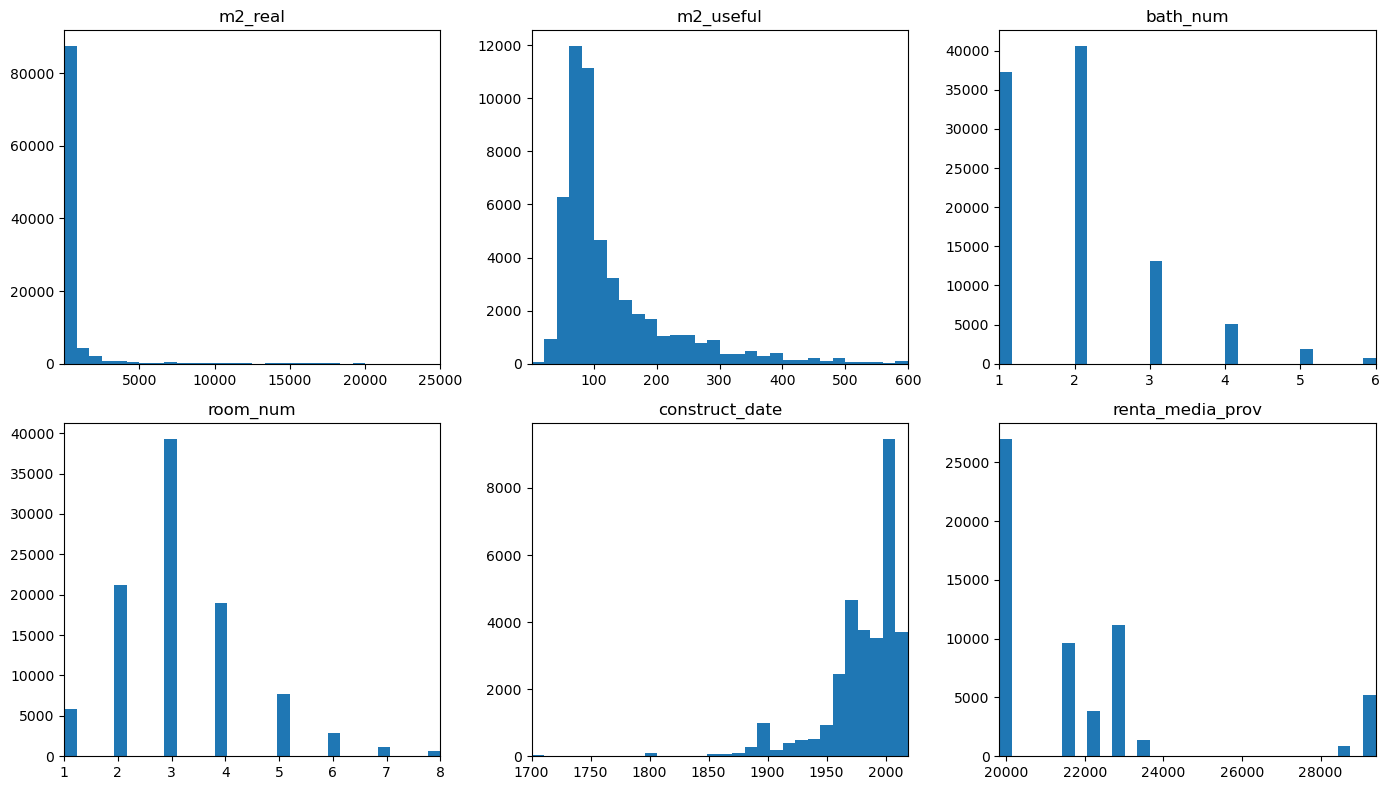

In [17]:
numeric_main = [
    "m2_real",
    "m2_useful",
    "bath_num",
    "room_num",
    "construct_date",
    "renta_media_prov"
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(14, 8)
)

for ax, col in zip(axes.flat, numeric_main):
    data = df[col].dropna()
    upper = data.quantile(0.99)

    ax.hist(data[data <= upper], bins=30)
    ax.set_title(col)
    ax.set_xlim(left=data.min(), right=upper)

plt.tight_layout()
plt.show()

> Para facilitar la interpretación visual, los histogramas se representan hasta el percentil 99 de cada variable. Los valores superiores no se eliminan del conjunto de datos y serán objeto de análisis específico cuando sea necesario.

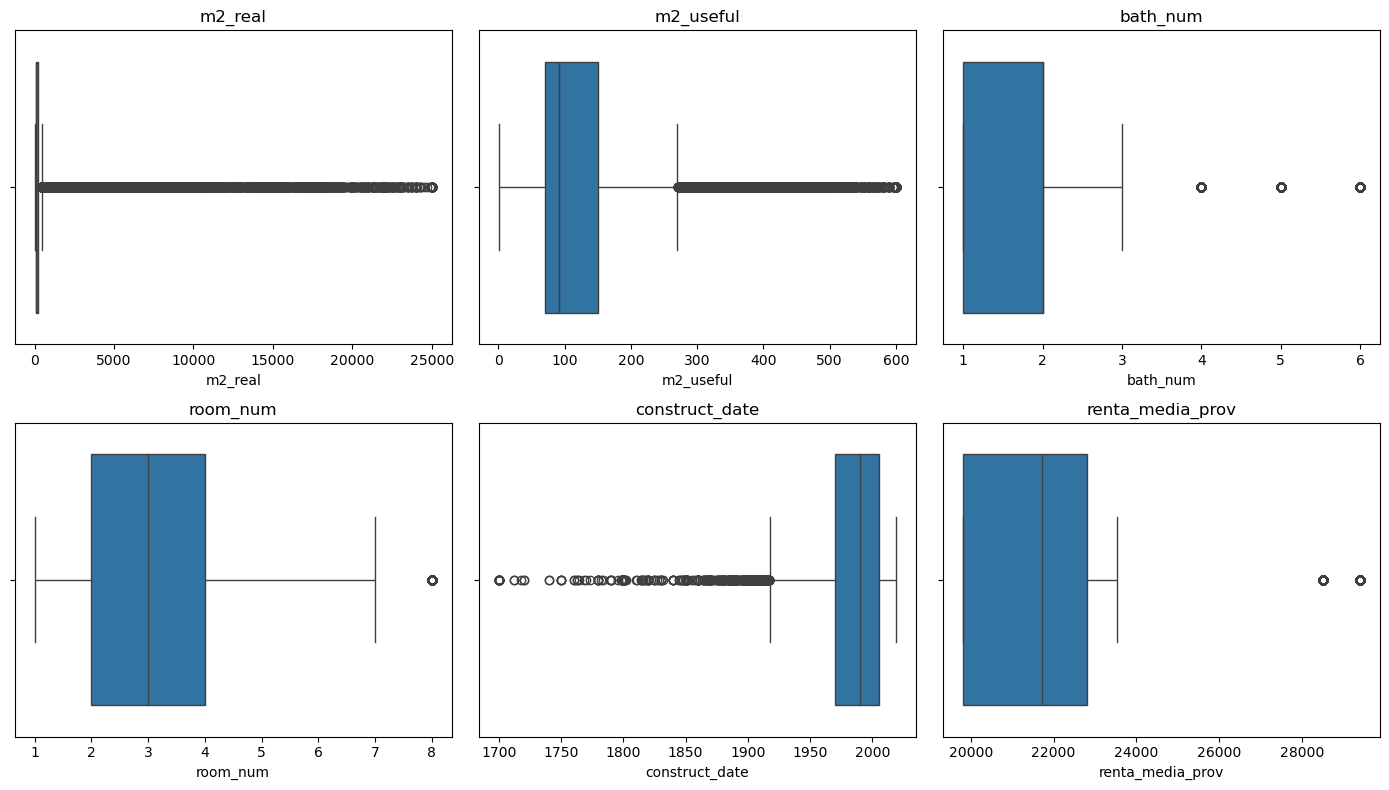

In [20]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(14, 8)
)

for ax, col in zip(axes.flat, numeric_main):
    data = df[col].dropna()
    upper = data.quantile(0.99)

    sns.boxplot(x=data[data <= upper], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [21]:
for col in numeric_main:
    print(f"\n{'='*60}")
    print(col)
    print(df[col].nlargest(10).to_list())


m2_real
[900000, 900000, 891800, 890000, 860000, 851360, 850000, 850000, 840000, 830000]

m2_useful
[140000.0, 91000.0, 16500.0, 14400.0, 7000.0, 6722.0, 6722.0, 5232.0, 5095.0, 4789.0]

bath_num
[84.0, 75.0, 58.0, 38.0, 34.0, 32.0, 30.0, 23.0, 20.0, 20.0]

room_num
[84.0, 73.0, 65.0, 58.0, 56.0, 36.0, 35.0, 35.0, 34.0, 32.0]

construct_date
[9999.0, 9999.0, 9999.0, 9999.0, 2109.0, 2109.0, 2108.0, 2102.0, 2099.0, 2022.0]

renta_media_prov
[29400.0, 29400.0, 29400.0, 29400.0, 29400.0, 29400.0, 29400.0, 29400.0, 29400.0, 29400.0]


In [34]:
cols_check = [
    "house_id",
    "house_type",
    "price",
    "m2_real",
    "m2_useful",
    "room_num",
    "bath_num",
    "construct_date",
    "loc_city",
    "loc_district"
]

print(df.loc[df["m2_real"] >= df["m2_real"].quantile(0.999),cols_check].sort_values("m2_real", ascending=False).head(20).to_string(index=False))

 house_id                   house_type    price  m2_real  m2_useful  room_num  bath_num  construct_date                   loc_city                       loc_district
 83962785                Casa o chalet  6000000   900000      625.0      13.0       5.0             NaN                    Bunyola                                NaN
 83534171  Casa o chalet independiente  3000000   900000        NaN       9.0       8.0             NaN                 El Pedroso                                NaN
 83317390                Finca rústica  3182000   891800     1648.0       3.0       2.0          1950.0                  Sencelles     Calle Glosador Llorenç Cartuxo
 39083809                   Casa rural  3450000   890000     1613.0       6.0       2.0          1880.0                  Sencelles                                NaN
 82593599                Finca rústica  1300000   860000       75.0       NaN       NaN             NaN                  Sencelles                                NaN
 848

In [23]:
print("Fechas posteriores a 2025:")
print((df["construct_date"] > 2025).sum())

print("\nFechas anteriores a 1800:")
print((df["construct_date"] < 1800).sum())

Fechas posteriores a 2025:
9

Fechas anteriores a 1800:
64


In [35]:
df.loc[df["construct_date"] > 2025, ["house_id", "house_type", "price", "construct_date", "loc_city"]].sort_values("construct_date", ascending=False).head(20)

,house_id,house_type,price,construct_date,loc_city
29856,84091568,Finca rústica,137000,9999.0,Manacor
30097,84275477,Piso,195000,9999.0,Manacor
48283,33328186,Piso,950000,9999.0,Bilbao
94436,34645997,Chalet adosado,420000,9999.0,Altafulla
43470,84221959,Piso,195000,2109.0,Getxo
58992,84221959,Piso,195000,2109.0,Getxo
30685,84264234,Piso,110250,2108.0,Felanitx
10459,39660868,Piso,475000,2102.0,Santa Eulalia del Río
24254,40010338,Casa o chalet independiente,452500,2099.0,Marratxi


In [36]:
df.loc[(df["bath_num"] >= 20) | (df["room_num"] >= 20),
    [
        "house_id",
        "house_type",
        "price",
        "m2_real",
        "m2_useful",
        "room_num",
        "bath_num",
        "loc_city"
    ]
].sort_values(["room_num", "bath_num"], ascending=False).head(30)

,house_id,house_type,price,m2_real,m2_useful,room_num,bath_num,loc_city
15493,83628968,Palacio,23000000,3,NaN,84.0,84.0,Valldemossa
90897,84163769,Casa o chalet independiente,1200000,3095,NaN,73.0,75.0,Espartinas
30497,39726934,Casa o chalet,4500000,39000,NaN,65.0,NaN,Manacor
86869,32433651,Caserón,4000000,7763,NaN,58.0,58.0,Ayllon
78456,30178388,Piso,3600000,1980,NaN,56.0,2.0,Roses
13382,83681116,Casa o chalet independiente,1850000,2000,NaN,36.0,20.0,Sant Josep de Sa Talaia
3680,29523967,Alquiler de Casa rural,5000,1900,2000.0,35.0,38.0,Oión
6206,84692493,Finca rústica,390000,60000,2750.0,35.0,15.0,Bonete
52359,37071101,Castillo,1850000,5250,NaN,34.0,4.0,Orozko
31467,84581626,Casa o chalet independiente,2800000,1458,NaN,32.0,32.0,Canyamel


### Conclusiones

El análisis univariante muestra que las principales variables numéricas presentan distribuciones asimétricas y una elevada presencia de valores extremos.

Las variables relacionadas con la superficie (`m2_real` y `m2_useful`) presentan una fuerte concentración en valores relativamente reducidos, junto con observaciones de superficie muy elevada. La inspección de estos registros muestra que algunos corresponden a viviendas de gran tamaño, fincas rústicas, casas rurales o castillos, por lo que no puede considerarse automáticamente que todos los valores extremos sean errores. No obstante, estas observaciones pueden tener una influencia significativa sobre el posterior modelado del precio y deberán tenerse en cuenta en el preprocesado definitivo.

En `bath_num` y `room_num` también se observan valores extremos muy elevados, llegando ambas variables hasta 84. La revisión de los registros afectados muestra algunos casos claramente poco habituales, aunque también aparecen propiedades de características excepcionales, como palacios, castillos o grandes fincas. Por tanto, estos valores se consideran candidatos a revisión y no se eliminan directamente en esta etapa.

La variable `construct_date` presenta un comportamiento diferente. Aunque la mayor parte de los valores se concentra en años de construcción plausibles, se detectan 9 registros con fechas posteriores a 2025, incluyendo valores como 2102, 2108, 2109 y 9999. Estos valores se consideran anómalos y deberán ser tratados en el preprocesado definitivo. También existen 64 registros anteriores a 1800, que deberán revisarse teniendo en cuenta el tipo de inmueble antes de decidir su tratamiento.

Tras la corrección realizada durante el preprocesado inicial, `renta_media_prov` presenta valores comprendidos entre 19.818 y 29.400, sin valores inferiores a 100, por lo que la anomalía de escala detectada durante la auditoría queda corregida.

En conjunto, el análisis pone de manifiesto la necesidad de revisar determinados valores extremos antes del modelado, pero se evita realizar una eliminación automática basada únicamente en criterios estadísticos, ya que algunos valores elevados pueden corresponder a propiedades reales de características excepcionales.

### 3.2. Variable objetivo: price

In [37]:
df["price"].describe()

count    9.981600e+04
mean     3.793929e+05
std      6.155011e+05
min      1.000000e+00
25%      1.200000e+05
50%      2.120000e+05
75%      3.950000e+05
max      2.300000e+07
Name: price, dtype: float64

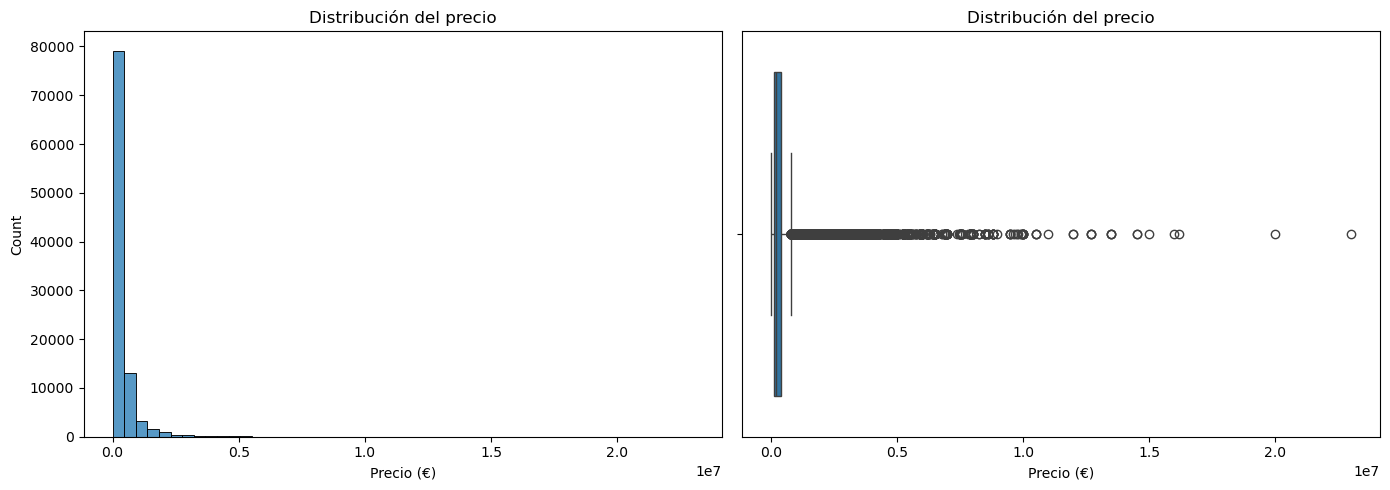

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["price"], bins=50, ax=axes[0])
axes[0].set_title("Distribución del precio")
axes[0].set_xlabel("Precio (€)")

sns.boxplot(x=df["price"], ax=axes[1])
axes[1].set_title("Distribución del precio")
axes[1].set_xlabel("Precio (€)")

plt.tight_layout()
plt.show()

In [45]:
print(df.groupby(df["house_type"].str.contains("Alquiler",case=False,na=False))["price"].describe())

              count           mean            std    min       25%       50%  \
house_type                                                                     
False       97205.0  389555.165043  620539.784511    1.0  127000.0  220000.0   
True         2611.0    1060.635006     529.814996  200.0     750.0     950.0   

                 75%         max  
house_type                        
False       400000.0  23000000.0  
True          1220.0      6500.0  


In [46]:
print(df.loc[df["price"] <= 10000,["price", "house_type"]].sort_values("price").head(50))

       price                               house_type
30688      1                                     Piso
11287      1                            Casa o chalet
97841    200  Alquiler de Casa o chalet independiente
97920    220                         Alquiler de Piso
97918    250               Alquiler de Casa de pueblo
97811    250               Alquiler de Chalet adosado
92236    250                         Alquiler de Piso
97825    275  Alquiler de Casa o chalet independiente
97909    280                         Alquiler de Piso
97778    280                         Alquiler de Piso
97780    280                         Alquiler de Piso
92225    289                         Alquiler de Piso
97878    300  Alquiler de Casa o chalet independiente
51231    300               Alquiler de Chalet adosado
97860    300                         Alquiler de Piso
92217    300               Alquiler de Chalet adosado
97864    300                         Alquiler de Piso
97865    300               A

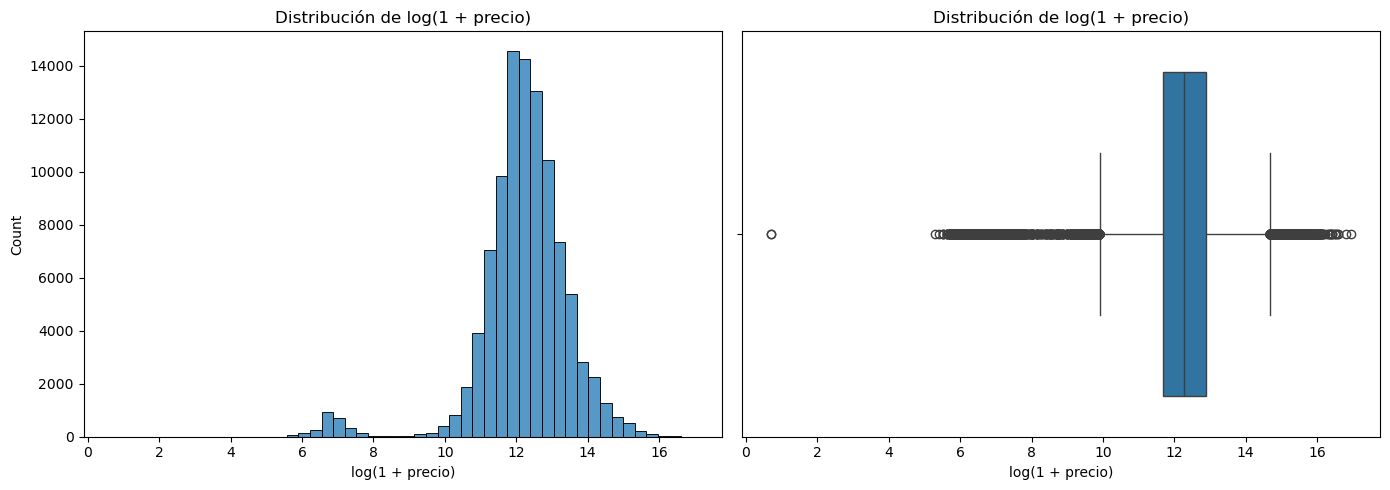

In [42]:
# Hacemos una transformación log a la variable price para visualizar de mejor manera la estructura de la variable

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(np.log1p(df["price"]), bins=50, ax=axes[0])
axes[0].set_title("Distribución de log(1 + precio)")
axes[0].set_xlabel("log(1 + precio)")

sns.boxplot(x=np.log1p(df["price"]), ax=axes[1])
axes[1].set_title("Distribución de log(1 + precio)")
axes[1].set_xlabel("log(1 + precio)")

plt.tight_layout()
plt.show()

### Conclusión sobre la variable objetivo `price`

Se ha detectado que el dataset contiene dos modalidades de operación: venta y alquiler. Los registros identificados como alquiler representan 2.611 observaciones (2,6 % aproximadamente) y presentan precios entre 200 y 6.500 €, claramente diferenciados de los precios correspondientes a las operaciones de venta. Por tanto, estos registros no deben considerarse valores atípicos de la variable price, sino observaciones correspondientes a una modalidad de operación diferente como lo es el alquiler.

Para el posterior modelado del precio de venta se trabajará exclusivamente con los registros de venta, evitando mezclar precios de adquisición con importes de alquiler. Adicionalmente, se han identificado dos registros de venta con un precio de tan solo 1 €, que se consideran valores anómalos y deberán revisarse o excluirse en el preprocesado final.

Por último, la fuerte asimetría observada en price hace recomendable considerar una transformación logarítmica de la variable objetivo durante la fase de modelado. Esta transformación se utiliza aquí únicamente con fines exploratorios y no se aplica todavía al dataset utilizado en el EDA.

### 3.3. Variables categóricas

In [49]:
# Identificamos las variables categóricas y su número de categorías

categorical_cols = df.select_dtypes(include="object").columns

cat_summary = pd.DataFrame({
    "n_unique": df[categorical_cols].nunique(dropna=False),
    "missing": df[categorical_cols].isna().sum(),
    "missing_%": df[categorical_cols].isna().mean() * 100
}).sort_values("n_unique", ascending=False)

cat_summary

,n_unique,missing,missing_%
ad_description,86150,4574,4.582432
loc_full,49368,0,0.000000
loc_district,23068,13747,13.772341
loc_neigh,17061,56310,56.413801
loc_street,9901,85685,85.842951
loc_city,1138,0,0.000000
ad_last_update,368,0,0.000000
garage,164,59189,59.298109
loc_zone,94,0,0.000000
floor,87,20307,20.344434


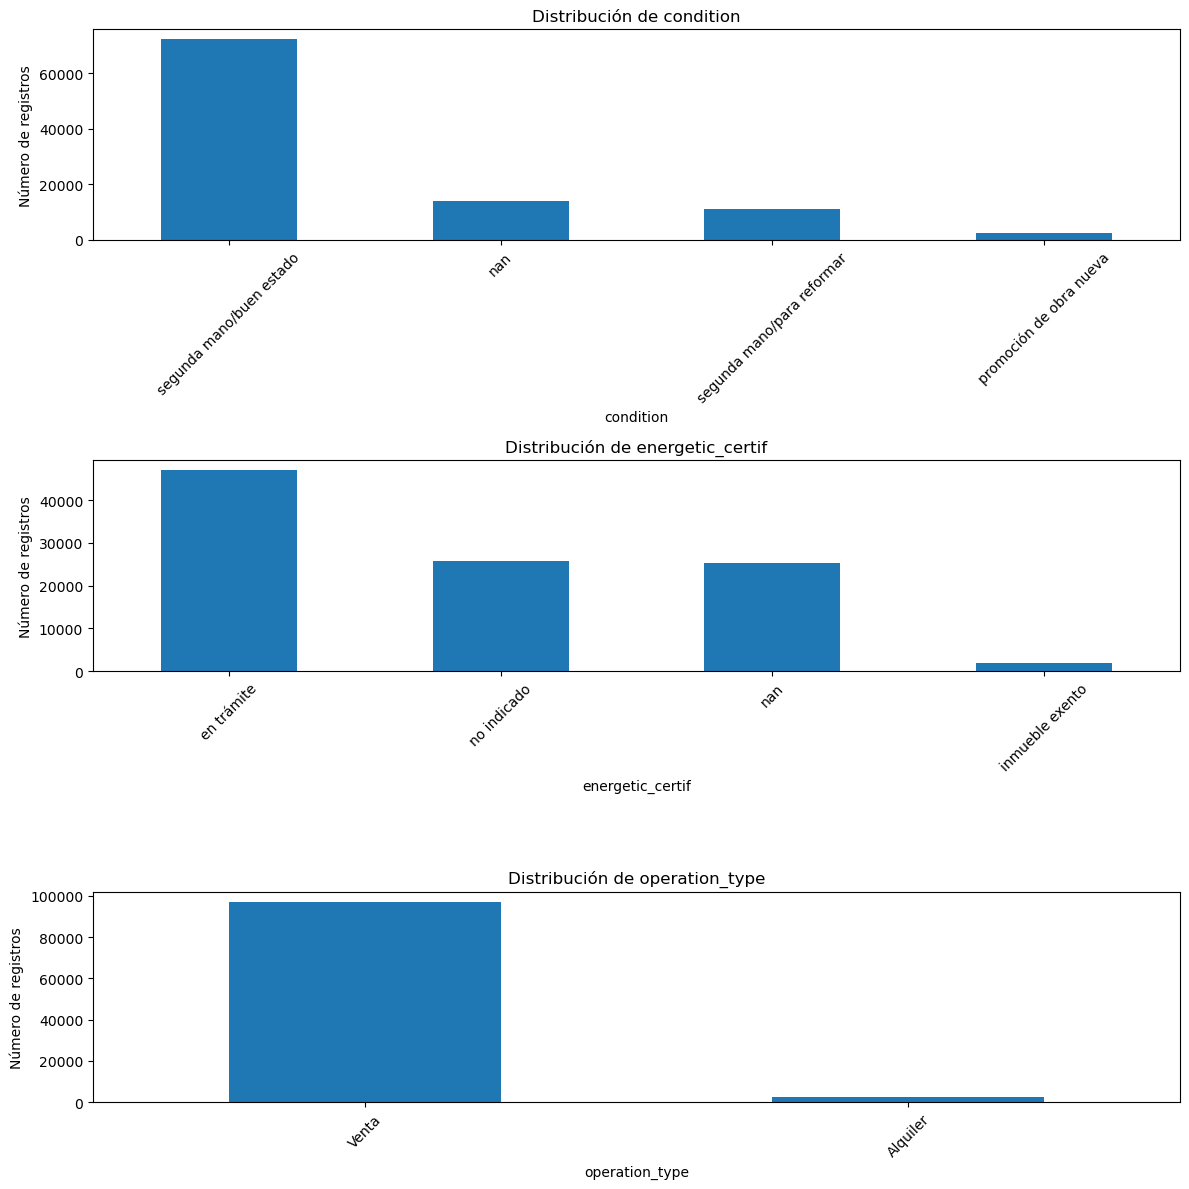

In [56]:
low_cardinality_cols = [
    "condition",
    "energetic_certif",
    "operation_type"
]

fig, axes = plt.subplots(
    len(low_cardinality_cols),
    1,
    figsize=(12, 4 * len(low_cardinality_cols))
)

for ax, col in zip(axes, low_cardinality_cols):
    df[col].value_counts(dropna=False).plot(
        kind="bar",
        ax=ax
    )
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Número de registros")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

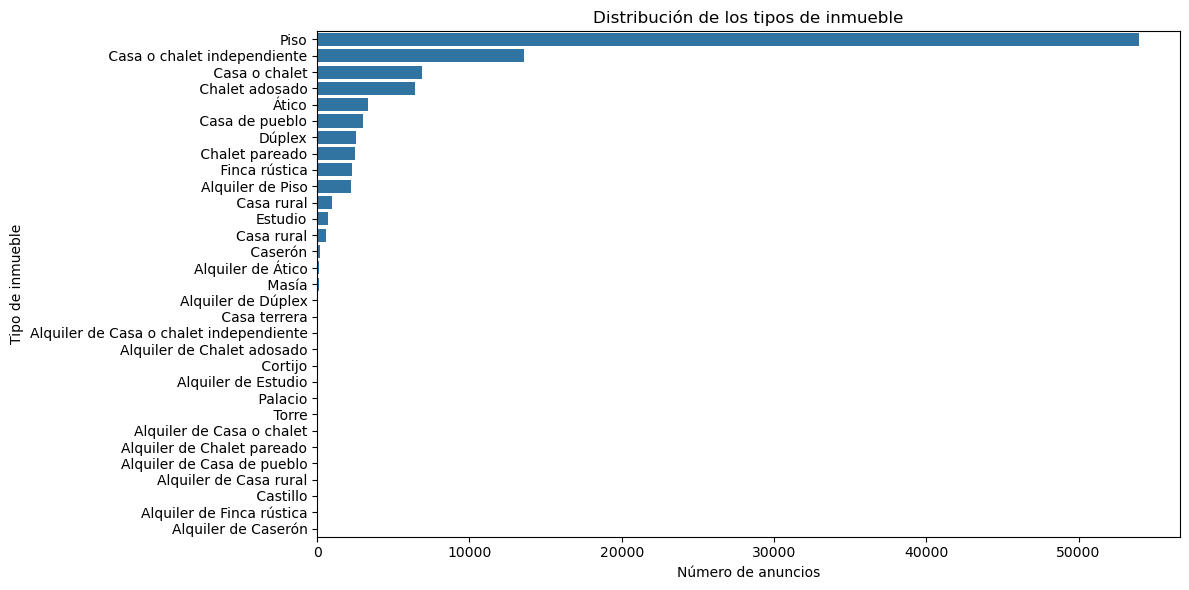

In [ ]:
# Distribución de house_type

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y="house_type",
    order=df["house_type"].value_counts().index
)

plt.title("Distribución de los tipos de inmueble")
plt.xlabel("Número de anuncios")
plt.ylabel("Tipo de inmueble")

plt.tight_layout()
plt.show()

In [58]:
for col in categorical_cols:
    if df[col].dtype == "object":
        n_original = df[col].nunique(dropna=False)
        n_clean = df[col].str.strip().str.lower().nunique(dropna=False)
        
        if n_original != n_clean:
            print(
                f"{col}: {n_original} categorías originales "
                f"-> {n_clean} tras normalizar"
            )

ad_description: 86150 categorías originales -> 86103 tras normalizar
house_type: 31 categorías originales -> 30 tras normalizar
loc_district: 23068 categorías originales -> 21955 tras normalizar
loc_full: 49368 categorías originales -> 47357 tras normalizar
loc_neigh: 17061 categorías originales -> 15861 tras normalizar
loc_street: 9901 categorías originales -> 9227 tras normalizar


### Conclusión sobre las variables categóricas

El análisis de las variables categóricas muestra una elevada heterogeneidad en el número de categorías y en el porcentaje de valores ausentes. Las variables `condition`, `energetic_certif` y `operation_type` presentan una cardinalidad reducida, por lo que pueden incorporarse al modelado mediante técnicas de codificación adecuadas.

La variable `house_type` presenta 31 categorías, aunque la distribución está fuertemente concentrada en unos pocos tipos de inmueble, especialmente `Piso` y `Casa o chalet independiente`. Las categorías minoritarias deberán valorarse durante el preprocesado para evitar una representación excesivamente dispersa.

También se han detectado posibles inconsistencias en la codificación de algunas categorías, como diferencias de espacios en blanco que pueden provocar que un mismo tipo de inmueble aparezca como categorías distintas. Estas inconsistencias deberán normalizarse durante la fase de preprocesado.

Por otro lado, las variables de localización (`loc_city`, `loc_district`, `loc_neigh`, `loc_street` y `loc_zone`) presentan una cardinalidad elevada y se analizarán de forma específica en el apartado de análisis geográfico. Asimismo, `ad_description` se considera una variable de texto libre y las variables relacionadas con fechas se tratarán como variables temporales, por lo que no se profundiza en ellas dentro de este apartado.


### 3.4. Variables binarias


In [ ]:
binary_cols = [
    "air_conditioner",
    "balcony",
    "built_in_wardrobe",
    "chimney",
    "garden",
    "lift",
    "reduced_mobility",
    "storage_room",
    "swimming_pool",
    "terrace"
]

# Tabla resumen de las variables binarias
binary_dist = (df[binary_cols].apply(lambda x: x.value_counts(normalize=True, dropna=False) * 100).T)

binary_dist

,0.0,1.0,NaN
air_conditioner,77.007694,22.992306,NaN
balcony,81.818546,18.181454,NaN
built_in_wardrobe,57.549892,42.450108,NaN
chimney,96.308207,3.691793,NaN
garden,72.123708,27.876292,NaN
lift,20.276308,38.613048,41.110644
reduced_mobility,91.921135,8.078865,NaN
storage_room,58.867316,41.132684,NaN
swimming_pool,81.574096,18.425904,NaN
terrace,52.047768,47.952232,NaN


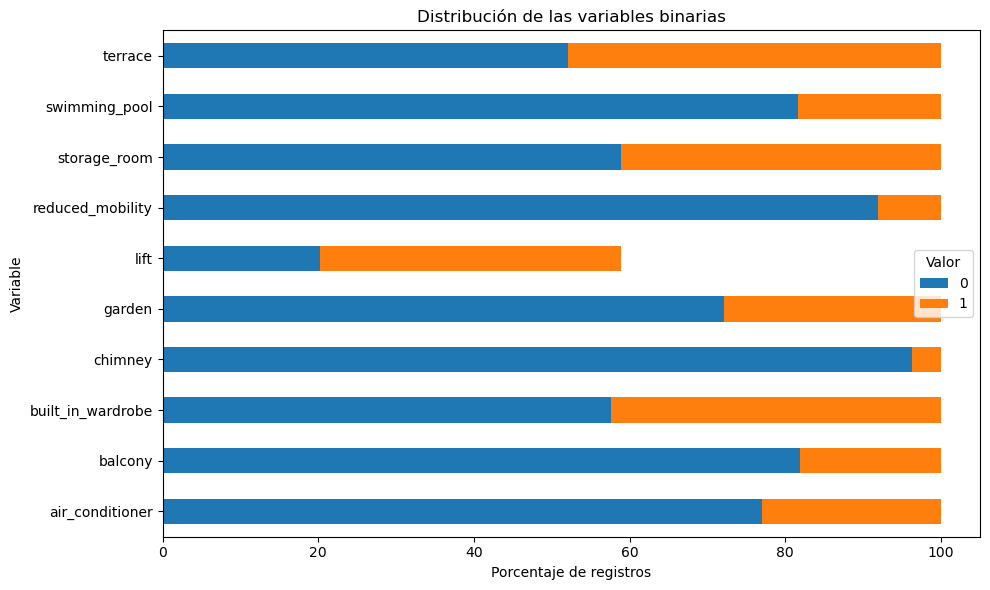

In [65]:
binary_dist_plot = binary_dist.copy()

# Eliminamos la columna NaN para representar únicamente 0 y 1
binary_dist_plot = binary_dist_plot[[0.0, 1.0]]

ax = binary_dist_plot.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6)
)

ax.set_title("Distribución de las variables binarias")
ax.set_xlabel("Porcentaje de registros")
ax.set_ylabel("Variable")
ax.legend(title="Valor", labels=["0", "1"])

plt.tight_layout()
plt.show()

### Conclusión sobre las variables binarias

Las variables binarias presentan, en general, una codificación consistente mediante valores 0 y 1. La distribución entre ambas categorías es desigual en la mayoría de las variables, aunque algunas, como `terrace`, `storage_room` y `built_in_wardrobe`, presentan una proporción relativamente equilibrada entre inmuebles que disponen de estas características y aquellos que no.

Por el contrario, variables como `chimney` y `reduced_mobility` presentan una frecuencia reducida de la categoría positiva, mientras que `air_conditioner`, `balcony`, `garden` y `swimming_pool` muestran un claro predominio de la categoría 0.

Destaca especialmente la variable `lift`, que presenta una elevada proporción de valores ausentes, con 41.035 registros sin información. Este comportamiento deberá tenerse en cuenta durante el preprocesado, ya que no resulta adecuado asumir automáticamente que un valor ausente equivale a la ausencia de ascensor.

## 4. Análisis bivariante

En este apartado se analiza la relación entre las principales variables explicativas y la variable objetivo `price`. El objetivo es identificar patrones, tendencias y diferencias entre grupos que puedan resultar relevantes para el posterior modelado predictivo.

Para evitar un análisis excesivamente extenso, se seleccionan únicamente aquellas variables y visualizaciones que aportan información relevante sobre el comportamiento del precio. El análisis se divide en variables numéricas, categóricas y binarias.

### Filtrado de operaciones de venta

Dado que el objetivo del análisis es predecir el precio de venta de los inmuebles, a partir de este apartado se consideran únicamente los registros correspondientes a operaciones de venta. De este modo, se evita que los importes mensuales asociados a los alquileres introduzcan distorsiones en el análisis de la relación entre las variables explicativas y el precio.

Se crea una copia independiente del conjunto de datos de venta para realizar el análisis bivariante:

Todas las visualizaciones y análisis posteriores de este apartado se realizan sobre `df_venta`.


In [99]:
df_venta = df[df["operation_type"] == "Venta"].copy()

### 4.1. Numéricas vs Price

En este apartado se analiza la relación entre las principales variables numéricas del inmueble y su precio. Se utilizarán gráficos de dispersión para identificar tendencias, asociaciones y posibles relaciones no lineales.

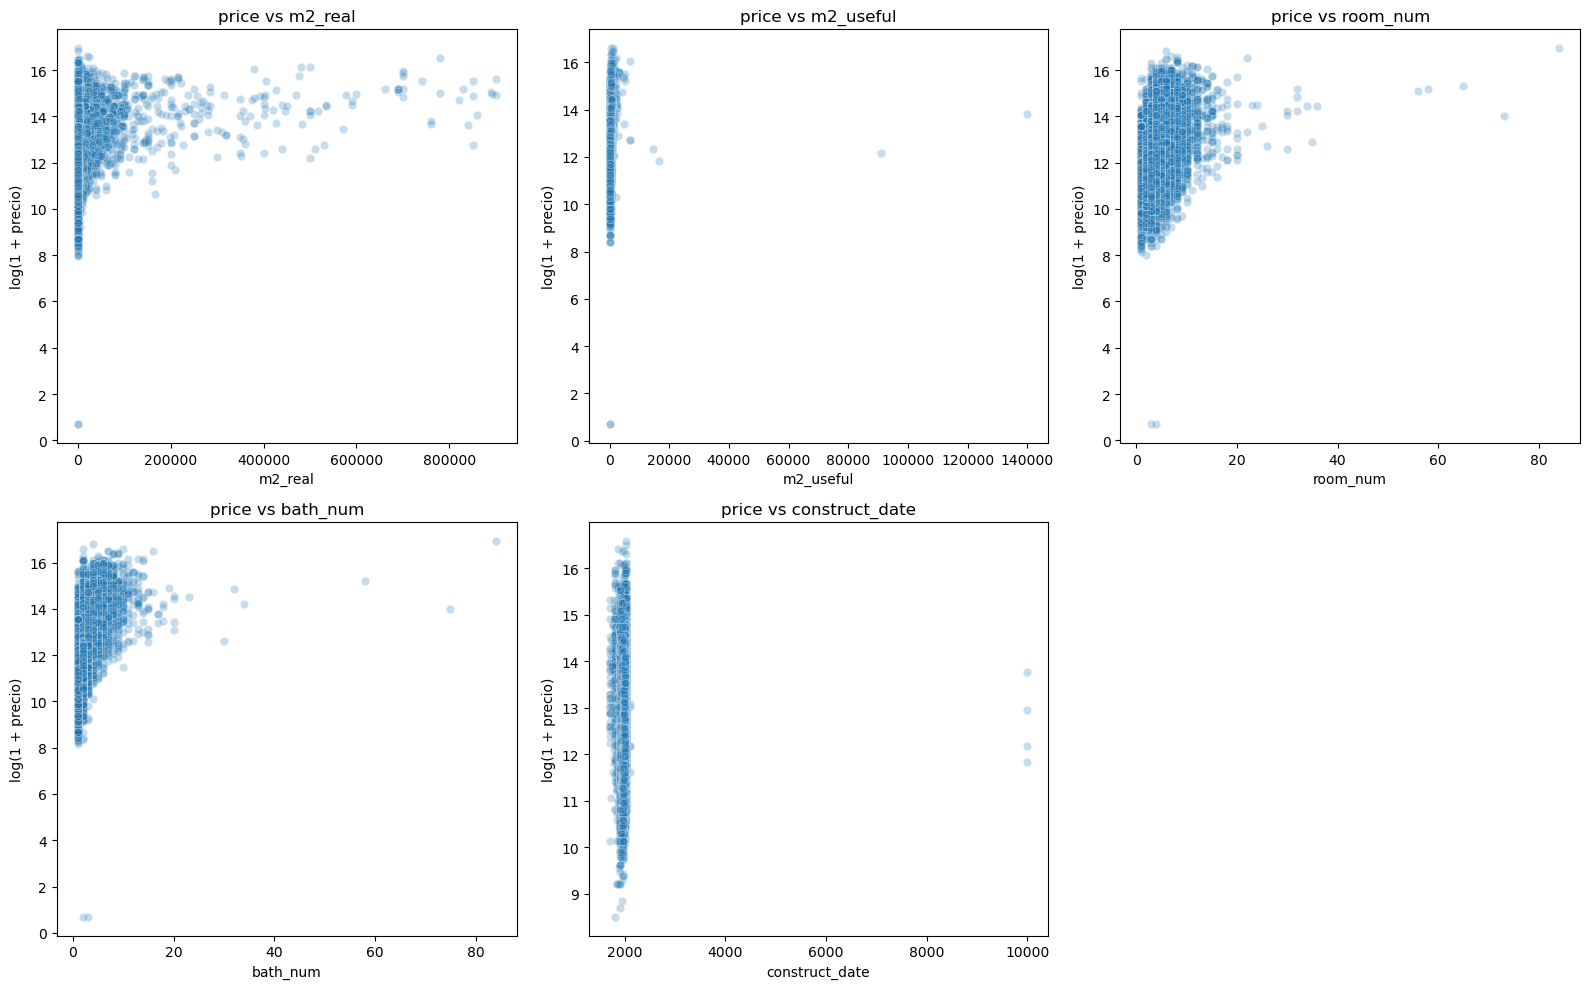

In [100]:
numeric_vars = [
    "m2_real",
    "m2_useful",
    "room_num",
    "bath_num",
    "construct_date"
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 10)
)

for ax, col in zip(axes.flat, numeric_vars):
    sns.scatterplot(
        data=df_venta,
        x=col,
        y=np.log1p(df_venta["price"]),
        alpha=0.25,
        ax=ax
    )
    ax.set_title(f"price vs {col}")
    ax.set_ylabel("log(1 + precio)")

# Eliminamos el sexto eje vacío
axes[1, 2].remove()

plt.tight_layout()
plt.show()

### Conclusión del análisis de variables numéricas

La transformación logarítmica de `price` permite visualizar con mayor claridad la relación entre la variable objetivo y las variables numéricas. Se observa una asociación positiva entre la superficie (`m2_real` y `m2_useful`) y el precio, aunque con una elevada dispersión y la presencia de valores extremos.

El número de habitaciones (`room_num`) y de baños (`bath_num`) también muestran una tendencia positiva con el precio, aunque con una dispersión considerable. Por su parte, `construct_date` no presenta una relación clara con el precio y muestra algunos valores extremos que deberán revisarse durante el preprocesado.

En conjunto, las variables relacionadas con las características y dimensiones del inmueble muestran una asociación visual con el precio, aunque estas relaciones no son completamente lineales. El análisis de correlaciones y de las relaciones conjuntas entre variables se abordará posteriormente en el análisis multivariante.


### 4.2. Categóricas vs Price

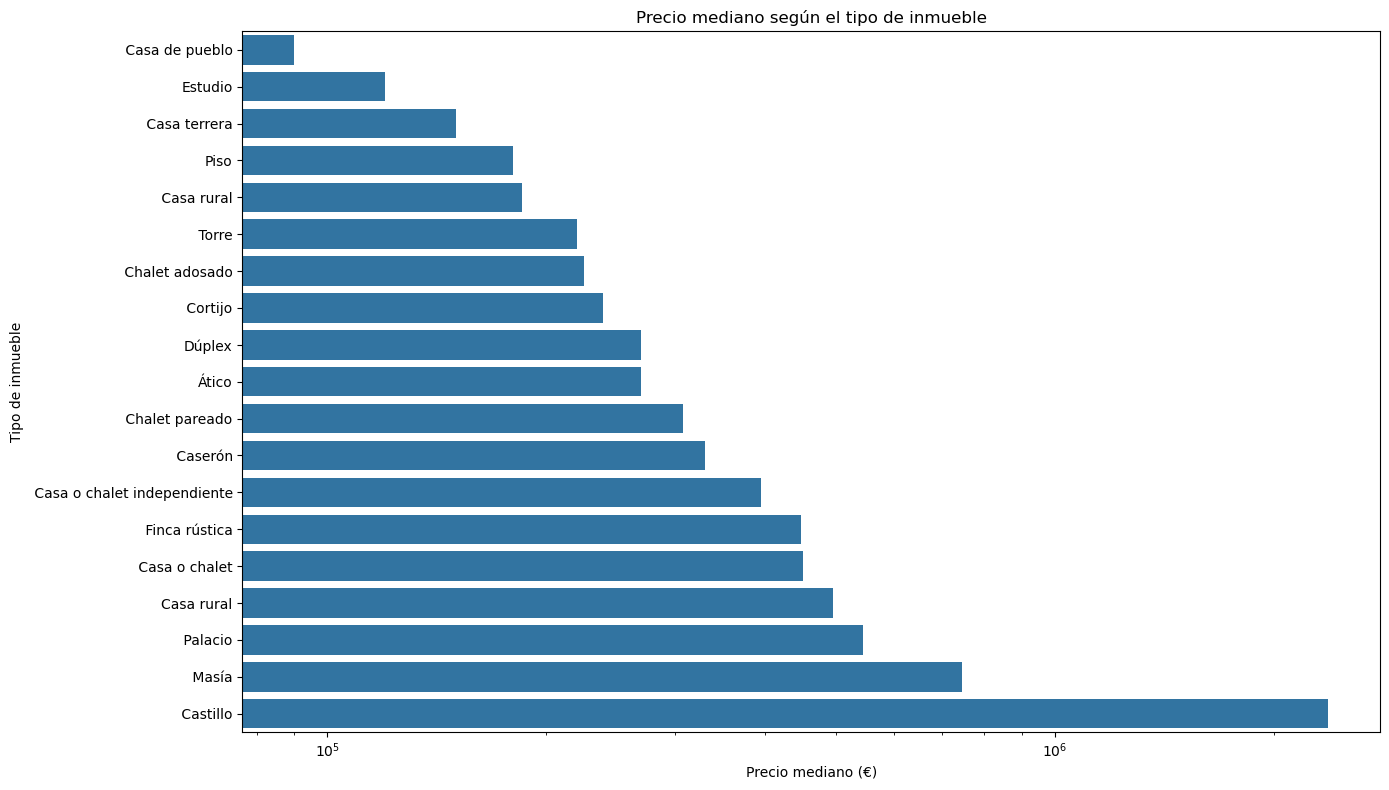

In [103]:
plt.figure(figsize=(14, 8))

order = (
    df_venta.groupby("house_type")["price"]
    .median()
    .sort_values()
    .index
)

sns.barplot(
    data=df_venta,
    x="price",
    y="house_type",
    order=order,
    estimator="median",
    errorbar=None
)

plt.xscale("log")
plt.xlabel("Precio mediano (€)")
plt.ylabel("Tipo de inmueble")
plt.title("Precio mediano según el tipo de inmueble")

plt.tight_layout()
plt.show()

El precio presenta una fuerte asimetría y numerosos valores extremos. Por ejemplo, en tipos como Castillo o Palacio puede haber algunos inmuebles con precios extraordinariamente elevados que hagan que la media aumente mucho, aunque no representen el precio habitual de esa categoría.

La mediana es mucho más robusta frente a esos valores extremos y, por tanto, permite comparar mejor el precio típico entre tipos de inmueble.

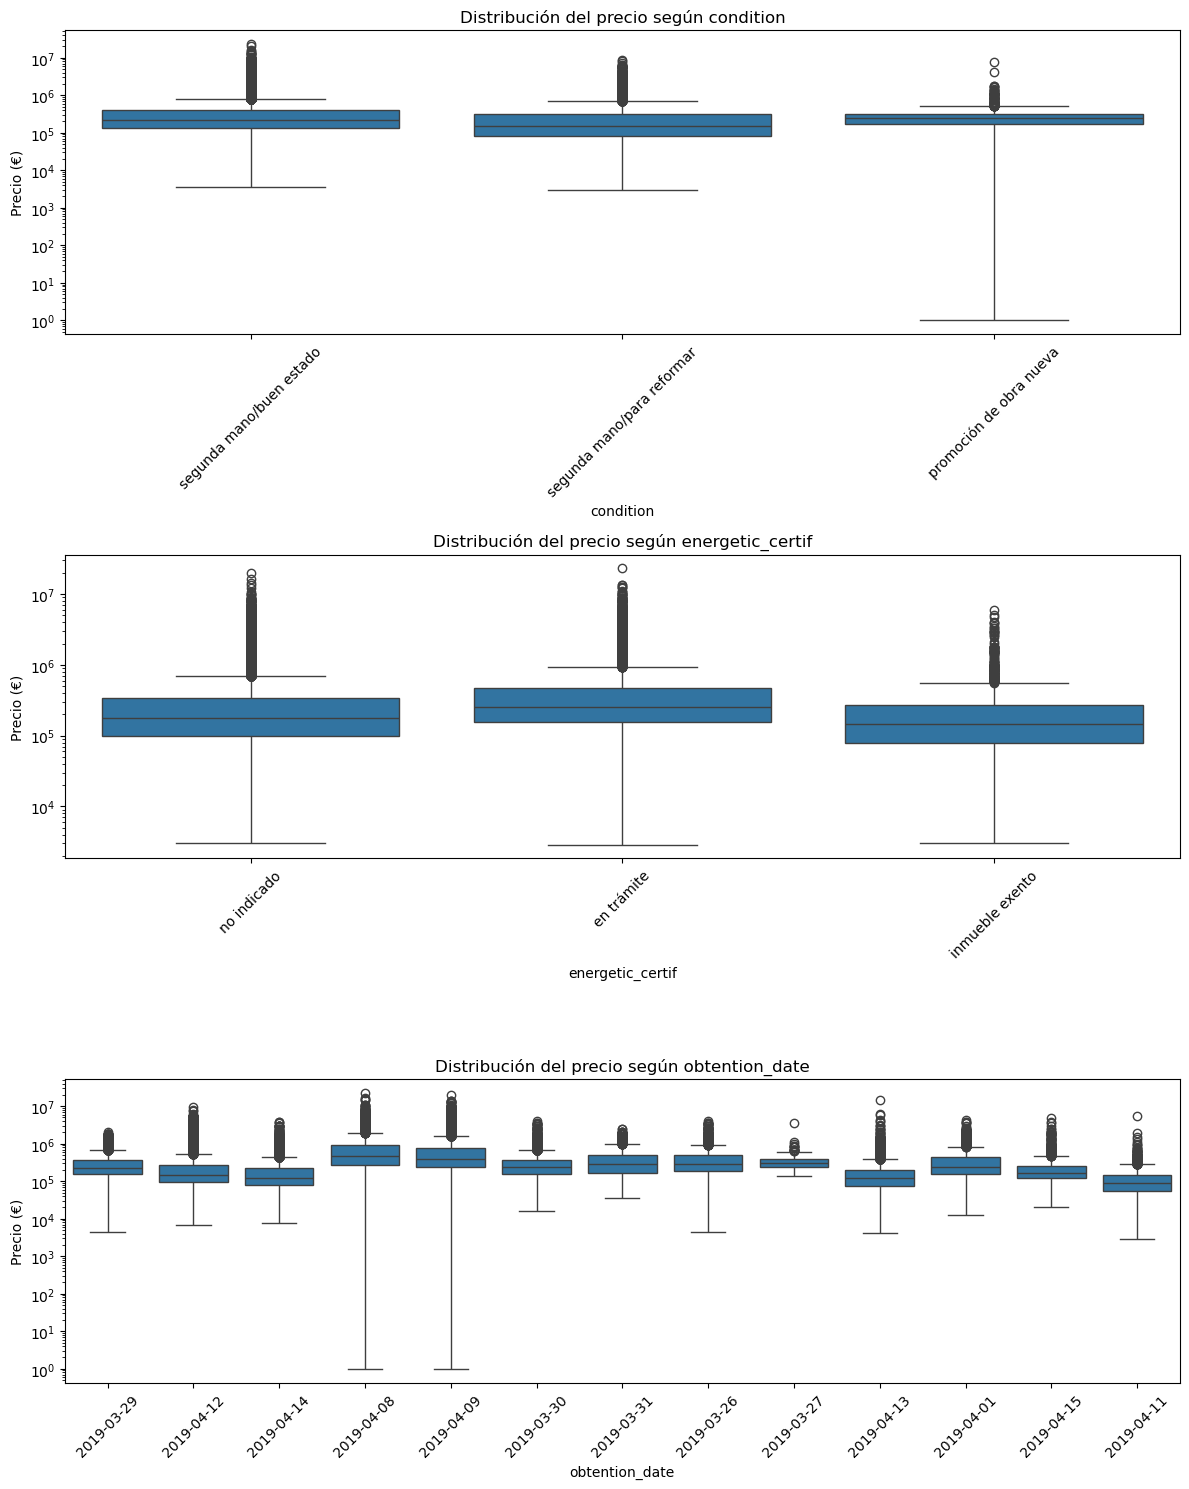

In [102]:
categorical_vars = [
    "condition",
    "energetic_certif",
    "obtention_date"
]

fig, axes = plt.subplots(
    len(categorical_vars),
    1,
    figsize=(12, 5 * len(categorical_vars))
)

for ax, col in zip(axes, categorical_vars):

    sns.boxplot(
        data=df_venta,
        x=col,
        y="price",
        ax=ax
    )

    ax.set_yscale("log")
    ax.set_title(f"Distribución del precio según {col}")
    ax.set_ylabel("Precio (€)")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Conclusión de las variables categóricas

El **tipo de inmueble** muestra diferencias claras en el precio mediano. Los inmuebles singulares, como `Castillo`, `Masía` o `Palacio`, presentan los precios más elevados, mientras que `Casa de pueblo`, `Estudio` y `Piso` se sitúan entre los valores más bajos. Esto indica que el tipo de inmueble es una variable con capacidad para diferenciar notablemente el precio.

En cuanto a la **condición del inmueble**, las diferencias son más moderadas: los inmuebles de obra nueva presentan precios ligeramente superiores, mientras que los de segunda mano muestran distribuciones bastante similares entre buen estado y necesidad de reforma.

El **certificado energético** también presenta diferencias apreciables. Los inmuebles con certificado `en trámite` muestran los precios más elevados, mientras que los clasificados como `inmueble exento` presentan precios medianos algo inferiores. No obstante, las tres categorías presentan una elevada dispersión y numerosos valores extremos.

Por último, `obtention_date` presenta diferencias entre fechas, con algunas jornadas concentrando precios medianos claramente superiores o inferiores. 

### 4.3. Binarias vs Price

In [104]:
binary_price = []

for col in binary_cols:
    if col == "operation_type":
        continue

    medians = df_venta.groupby(col)["price"].median()

    binary_price.append({
        "variable": col,
        "sin": medians.get(0),
        "con": medians.get(1)
    })

binary_price = pd.DataFrame(binary_price)

binary_price

,variable,sin,con
0,air_conditioner,190000.0,349900.0
1,balcony,214000.0,245000.0
2,built_in_wardrobe,180000.0,278000.0
3,chimney,220000.0,290000.0
4,garden,180000.0,360000.0
5,lift,140000.0,225000.0
6,reduced_mobility,216732.5,248000.0
7,storage_room,190000.0,260000.0
8,swimming_pool,189000.0,458225.0
9,terrace,169000.0,290000.0


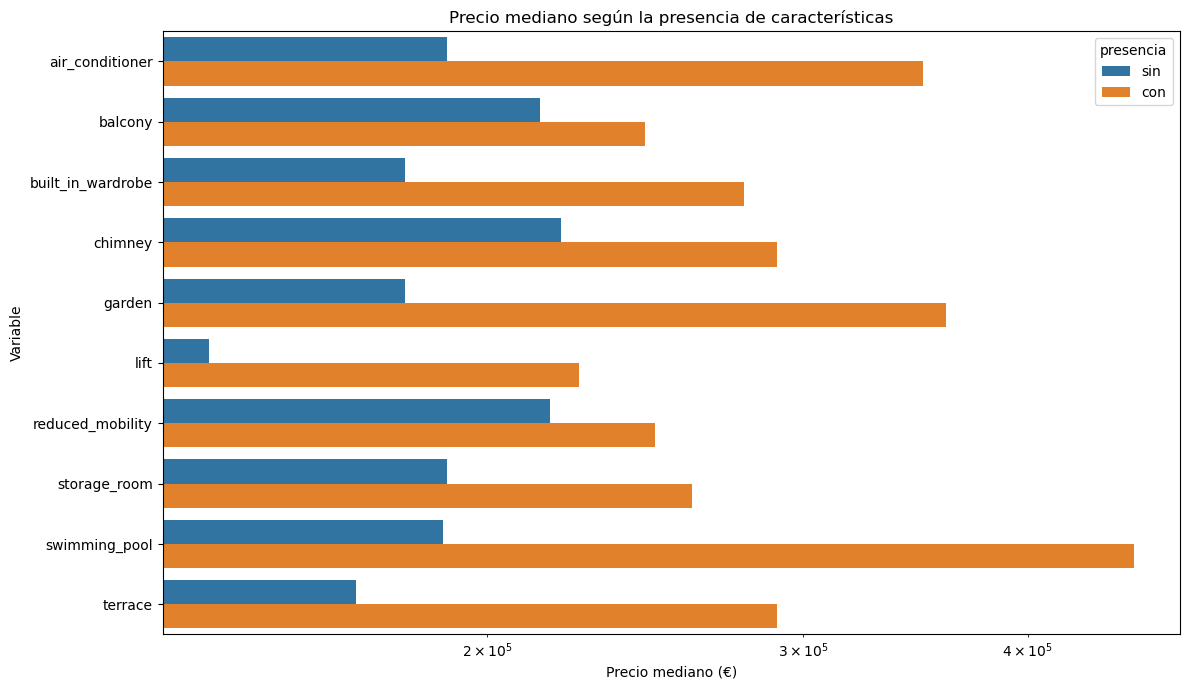

In [106]:
binary_price_long = binary_price.melt(
    id_vars="variable",
    value_vars=["sin", "con"],
    var_name="presencia",
    value_name="precio_mediano"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=binary_price_long,
    x="precio_mediano",
    y="variable",
    hue="presencia"
)

plt.xscale("log")
plt.xlabel("Precio mediano (€)")
plt.ylabel("Variable")
plt.title("Precio mediano según la presencia de características")

plt.tight_layout()
plt.show()

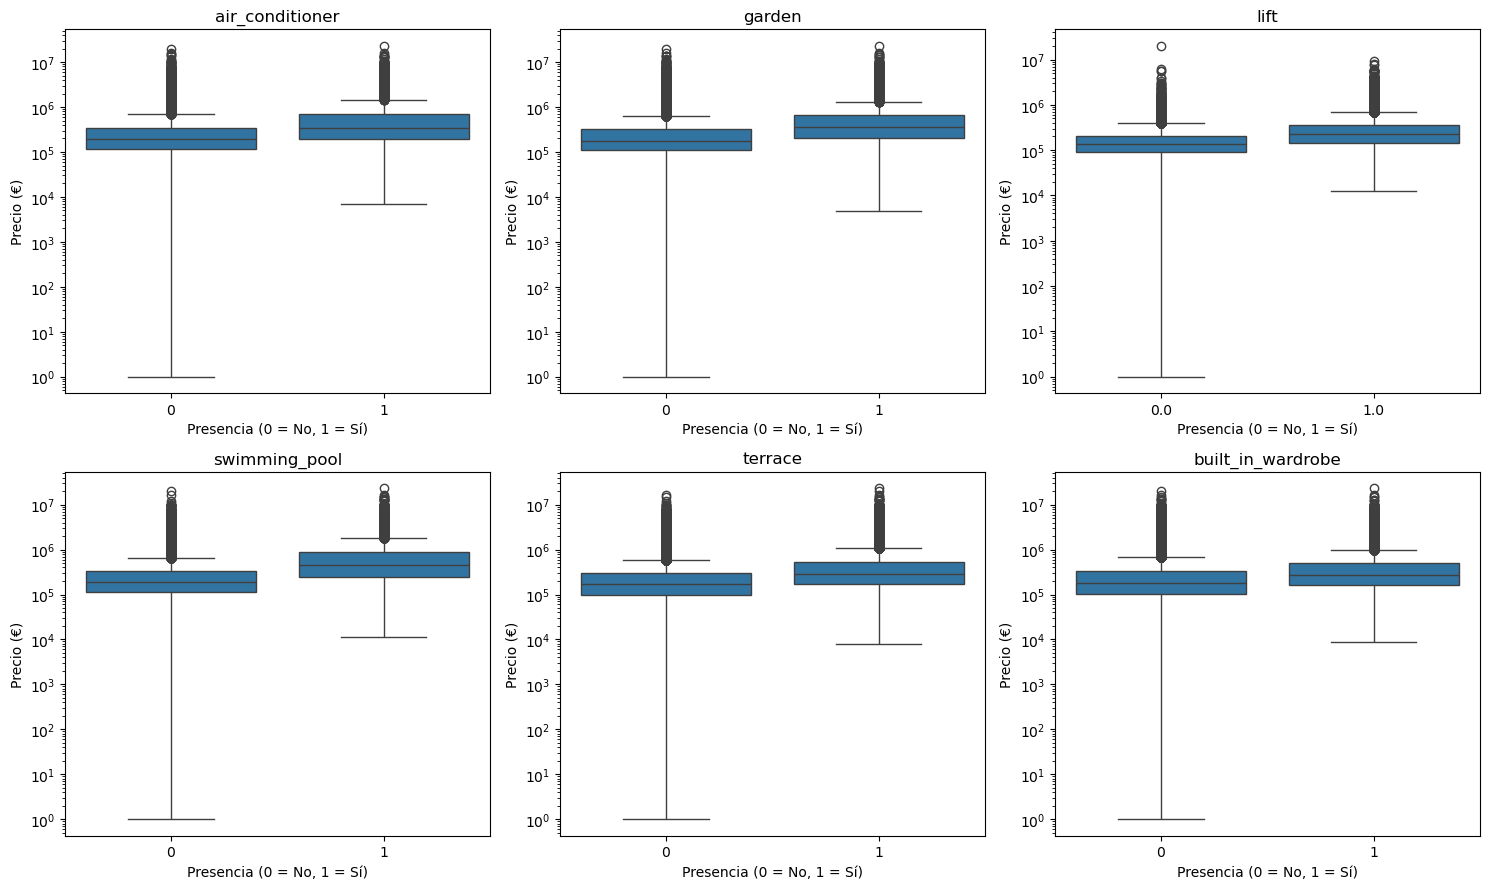

In [107]:
binary_vars_selected = [
    "air_conditioner",
    "garden",
    "lift",
    "swimming_pool",
    "terrace",
    "built_in_wardrobe"
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

for ax, col in zip(axes.flat, binary_vars_selected):

    sns.boxplot(
        data=df_venta,
        x=col,
        y="price",
        ax=ax
    )

    ax.set_yscale("log")
    ax.set_title(col)
    ax.set_xlabel("Presencia (0 = No, 1 = Sí)")
    ax.set_ylabel("Precio (€)")

plt.tight_layout()
plt.show()

### Conclusión de las variables binarias

Las variables binarias muestran diferencias apreciables en el precio mediano según la presencia de determinadas características. Destaca especialmente la **piscina**, seguida del **jardín**, el **aire acondicionado** y la **terraza**, cuyos inmuebles presentan precios medianos claramente superiores a los que no disponen de estas características.

Otras variables, como `built_in_wardrobe`, `storage_room` y `lift`, también muestran diferencias positivas, aunque de menor magnitud. En cambio, `balcony` y `reduced_mobility` presentan diferencias más reducidas.

En conjunto, las variables binarias parecen aportar información relevante sobre el precio, aunque estas diferencias no deben interpretarse como efectos causales, ya que pueden estar relacionadas con otras características del inmueble. Además, el elevado porcentaje de valores ausentes de `lift` deberá tenerse en cuenta en su interpretación y posterior tratamiento.


## 5. Análisis geográfico

En este análisis se trabajará exclusivamente con los inmuebles en venta (df_venta), excluyendo los anuncios de alquiler. De este modo, las comparaciones de precios entre zonas se realizan sobre el mismo dataset que en el apartado anterior.

### 5.1. Distribución por zonas

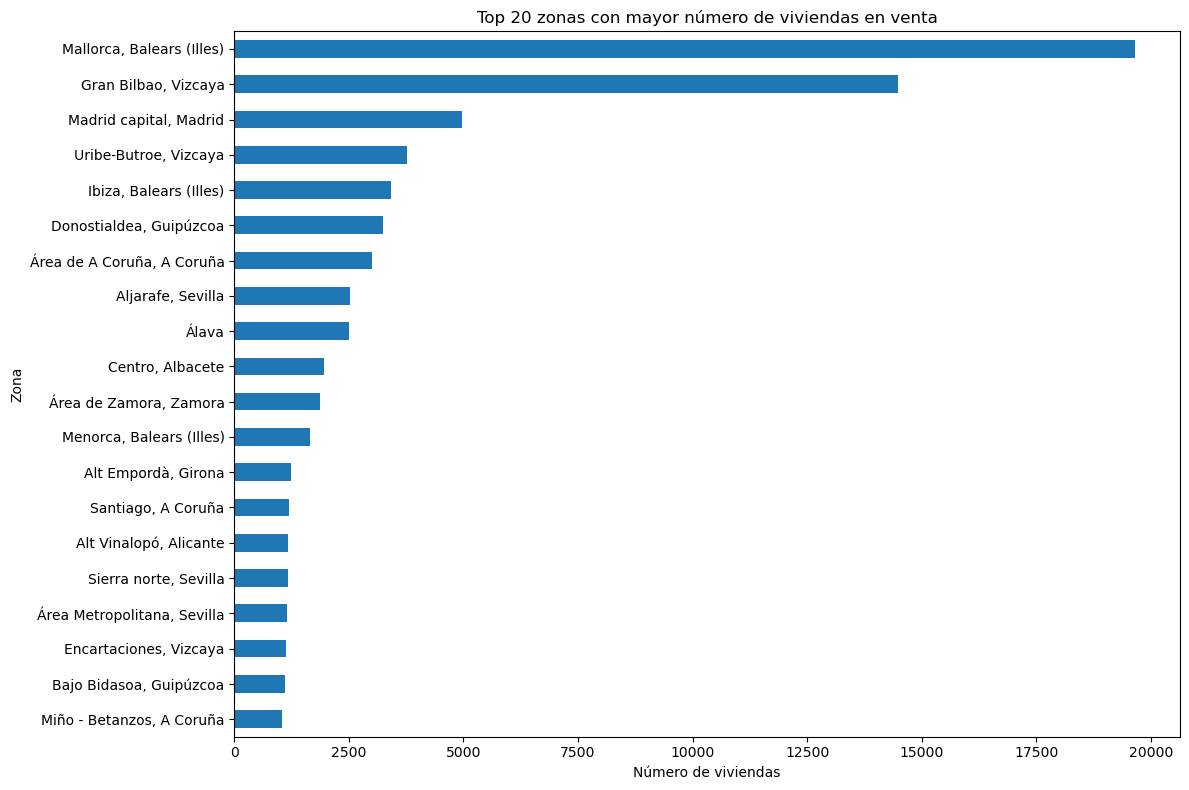

In [112]:
# Top 20 zonas con mayor número de viviendas en venta

top_zones = (
    df_venta["loc_zone"]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(12, 8))

top_zones.plot(kind="barh")

plt.title("Top 20 zonas con mayor número de viviendas en venta")
plt.xlabel("Número de viviendas")
plt.ylabel("Zona")

plt.tight_layout()
plt.show()

### 5.2. Precio por zona

In [113]:
zone_price = (
    df_venta.groupby("loc_zone")["price"]
    .agg(["median", "count"])
    .rename(columns={"median": "price_median"})
)

zone_price.sort_values("price_median", ascending=False).head(10)

,price_median,count
loc_zone,,
Balears (Illes),1200000.0,100
"Ibiza, Balears (Illes)",771375.0,3422
"Mallorca, Balears (Illes)",395000.0,19649
"Uribe-Butroe, Vizcaya",390000.0,3767
"Zuya, Álava",365000.0,198
"Menorca, Balears (Illes)",330000.0,1651
"Donostialdea, Guipúzcoa",320000.0,3242
"Bajo Bidasoa, Guipúzcoa",310000.0,1107
"Gran Bilbao, Vizcaya",258000.0,14473


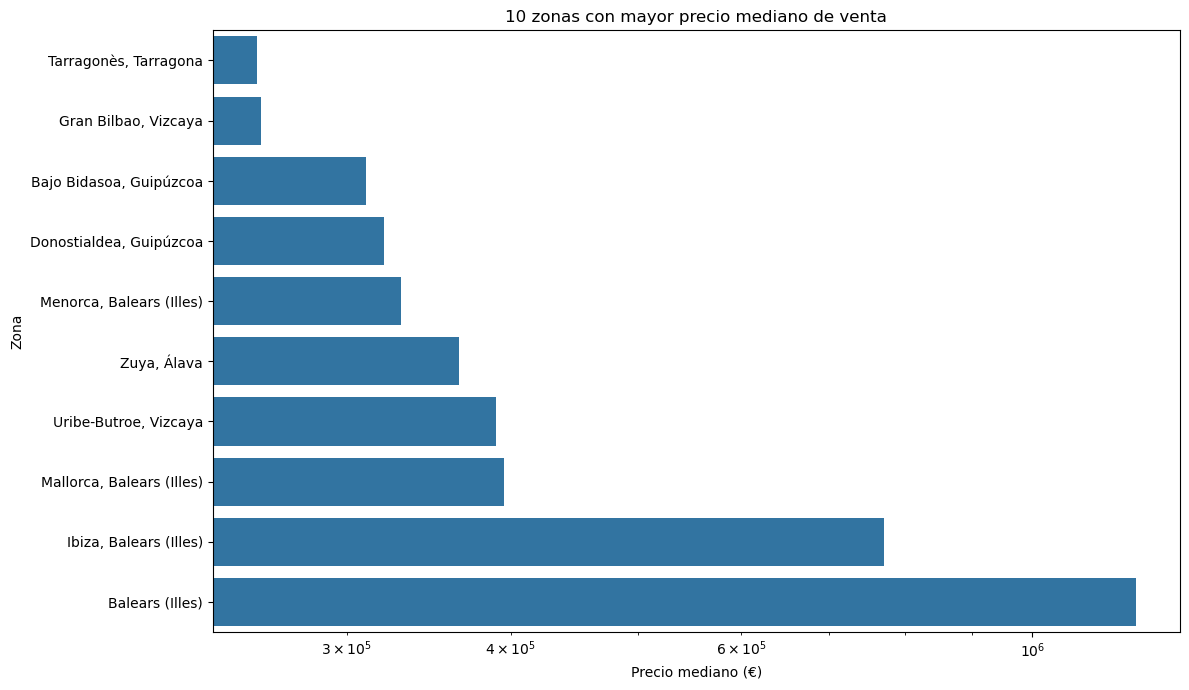

In [114]:
top_zones = (
    zone_price
    .sort_values("price_median", ascending=False)
    .head(10)
    .sort_values("price_median")
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_zones.reset_index(),
    x="price_median",
    y="loc_zone"
)

plt.xscale("log")
plt.xlabel("Precio mediano (€)")
plt.ylabel("Zona")
plt.title("10 zonas con mayor precio mediano de venta")

plt.tight_layout()
plt.show()

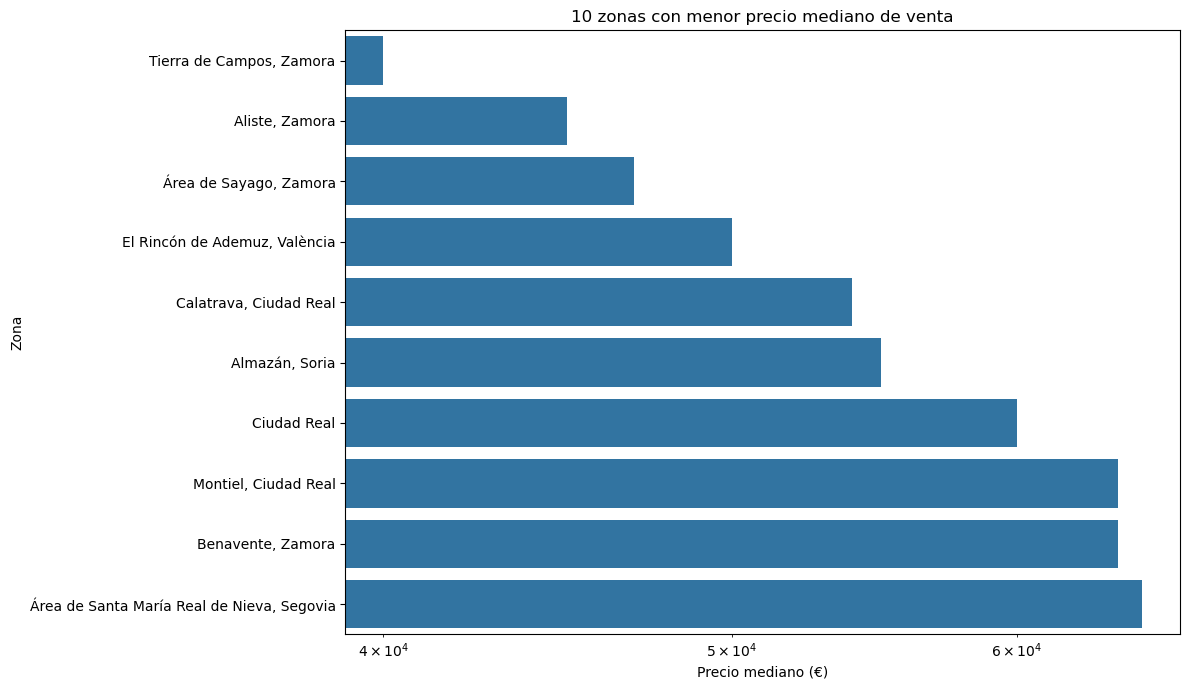

In [115]:
bottom_zones = (
    zone_price
    .sort_values("price_median", ascending=True)
    .head(10)
    .sort_values("price_median")
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=bottom_zones.reset_index(),
    x="price_median",
    y="loc_zone"
)

plt.xscale("log")
plt.xlabel("Precio mediano (€)")
plt.ylabel("Zona")
plt.title("10 zonas con menor precio mediano de venta")

plt.tight_layout()
plt.show()

### Conclusión

El precio de venta presenta **diferencias muy marcadas según la zona geográfica**. Las zonas con precios medianos más elevados se concentran principalmente en **Baleares**, destacando especialmente Ibiza y Mallorca, mientras que las zonas con precios más bajos se localizan mayoritariamente en áreas del interior, como Zamora o Ciudad Real.

No obstante, estos resultados deben interpretarse teniendo en cuenta el **número de observaciones de cada zona**, ya que algunas presentan una muestra reducida y, por tanto, sus medianas son menos representativas. En conjunto, la localización aparece como un factor relevante en el precio de la vivienda.

### 5.3. Precio por $m^2$ por zona

Para analizar el precio de la vivienda en términos relativos al tamaño del inmueble, se calcula una nueva variable `price_m2` como el cociente entre el precio de venta y la superficie real.

In [121]:
df_price_m2 = df_venta.copy()

df_price_m2["price_m2"] = (df_price_m2["price"] / df_price_m2["m2_real"])

In [123]:
# Comparamos el precio por metro cuadrado entre zonas

zone_price_m2 = (
    df_price_m2
    .groupby("loc_zone")["price_m2"]
    .agg(["median", "count"])
    .query("count >= 200")
    .sort_values("median", ascending=False)
)

zone_price_m2.head(10)

,median,count
loc_zone,,
"Ibiza, Balears (Illes)",3407.407407,3422
"Donostialdea, Guipúzcoa",3257.487091,3242
"Madrid capital, Madrid",2941.169118,4974
"Gran Bilbao, Vizcaya",2666.666667,14473
"Bajo Bidasoa, Guipúzcoa",2424.242424,1107
"Uribe-Butroe, Vizcaya",2333.333333,3767
"Urola Kosta, Guipúzcoa",2142.857143,352
Álava,2138.732959,2496
"Lea-Artibai, Vizcaya",2138.592751,394


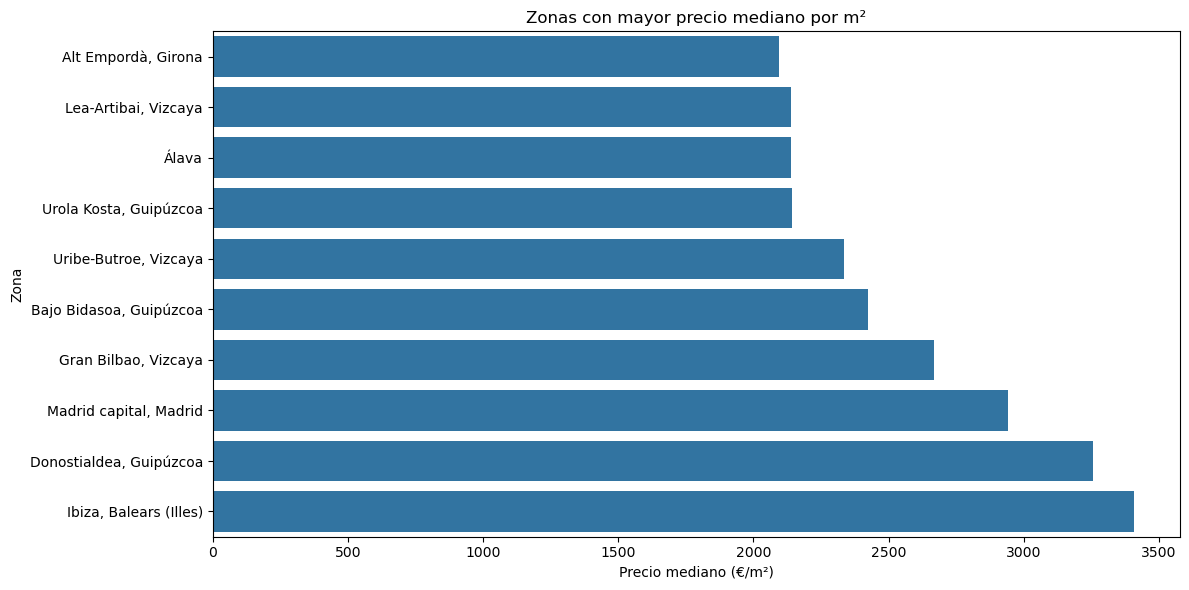

In [124]:
plt.figure(figsize=(12, 6))

top_zones = zone_price_m2.head(10).sort_values("median")

sns.barplot(
    x=top_zones["median"],
    y=top_zones.index
)

plt.xlabel("Precio mediano (€/m²)")
plt.ylabel("Zona")
plt.title("Zonas con mayor precio mediano por m²")

plt.tight_layout()
plt.show()

### Conclusión: precio por $m^2$ según la zona

El precio mediano por $m^2$ presenta **diferencias geográficas claras**. Ibiza destaca con el valor más elevado (3.407 €/$m^2$), seguida de Donostialdea (3.257 €/$m^2$) y Madrid capital (2.941 €/$m^2$).

En el extremo inferior del grupo analizado se encuentran Alt Empordà, Lea-Artibai y Álava, con valores próximos a **2.100–2.140 €/$m^2$**. En conjunto, los resultados confirman que la **localización influye notablemente en el precio relativo de la vivienda**.


## 6. Análisis multivariante

En este apartado se analiza de forma conjunta la relación entre las principales variables numéricas del conjunto de datos, con el objetivo de identificar relaciones relevantes y posibles redundancias entre las variables antes de abordar el modelado.

### 6.1. Matriz de correlación

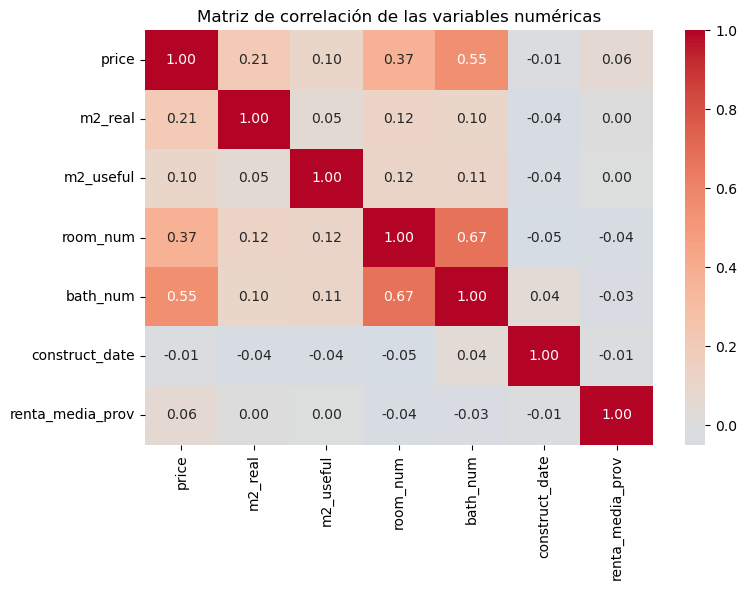

In [127]:
numeric_vars = [
    "price",
    "m2_real",
    "m2_useful",
    "room_num",
    "bath_num",
    "construct_date",
    "renta_media_prov"
]


corr = df_venta[numeric_vars].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Matriz de correlación de las variables numéricas")
plt.tight_layout()
plt.show()

### Relaciones relevantes

La matriz de correlación muestra que el número de baños presenta la mayor correlación lineal con el precio (`r = 0.55`), seguido del número de habitaciones (`r = 0.37`) y de la superficie real (`r = 0.21`). La superficie útil (`m2_useful`) presenta una correlación todavía más débil con el precio (`r = 0.10`), mientras que el resto de variables numéricas muestran relaciones lineales débiles. Por su parte, `renta_media_prov` presenta una correlación cercana a cero con el precio.

También destaca la correlación entre `room_num` y `bath_num` (`r = 0.67`), lo que indica que ambas variables contienen información parcialmente relacionada. No obstante, dado que ambas presentan relación con el precio, se mantendrán inicialmente y se evaluará su utilidad durante la fase de modelado.

En conjunto, las correlaciones sugieren que ninguna variable numérica por sí sola explica de forma suficiente el precio, por lo que será necesario considerar conjuntamente las características del inmueble y su localización. Además, las bajas correlaciones de algunas variables no implican necesariamente que carezcan de utilidad predictiva, ya que pueden aportar información mediante relaciones no lineales o en combinación con otras variables, como paso con `m2_real` y `m2_useful` por ejemplo.

## 7. Conclusiones del EDA

Un resumen **muy conciso** de lo que hemos aprendido en cada apartado:

* **Variable objetivo `price`**

  * Distribución muy asimétrica y con cola derecha.
  * Se identificaron alquileres mezclados con ventas.
  * Los alquileres tienen precios claramente diferenciados.
  * Se detectaron dos ventas con `price = 1 €` que deben revisarse.

* **Variables categóricas**

  * `house_type` presenta varias categorías y algunas de ellas tienen muy pocos registros.
  * Existen variables con muchos niveles y/o elevada proporción de ausentes.

* **Variables binarias**

  * En general están correctamente codificadas como 0/1.
  * `lift` destaca por su elevado porcentaje de `NaN`.
  * Se comprobó que los ausentes de `lift` están mayoritariamente asociados a viviendas unifamiliares/chalets, información que puede utilizarse posteriormente para decidir su tratamiento.

* **Análisis bivariante**

  * `bath_num`, `room_num` y las características de superficie muestran relaciones relevantes con el precio.
  * Las características como piscina, jardín, aire acondicionado, terraza, etc. presentan diferencias de precio entre categorías.
  * Se trabajó exclusivamente con `df_venta` para evitar mezclar venta y alquiler.

* **Análisis geográfico**

  * Existen diferencias importantes de precio entre zonas.
  * Ibiza, Mallorca, Donostialdea y determinadas zonas del País Vasco destacan por sus precios elevados.
  * El precio por m² permite apreciar diferencias geográficas que no se observan únicamente mediante el precio absoluto.

* **Análisis multivariante**

  * `bath_num` presenta la mayor correlación lineal con `price` (`0.55`).
  * `room_num` y `bath_num` presentan cierta redundancia (`0.67`).
  * `m2_real` tiene una relación más clara con el precio que `m2_useful`, aunque ambas deben mantenerse inicialmente.
  * `renta_media_prov` presenta una correlación lineal muy baja, pero no se descarta todavía su utilidad predictiva.



## 8. Decisiones para el preprocesado definitivo

| Aspecto                 | Decisión                                                                     |
| ----------------------- | ---------------------------------------------------------------------------- |
| Alquileres              | Eliminar registros con `operation_type = "Alquiler"`                         |
| `price = 1 €`           | Revisar y excluir los dos registros anómalos                                 |
| Precios extremos altos  | No eliminar automáticamente; revisar y mantener si son plausibles            |
| Asimetría de `price`    | Evaluar `log1p(price)` en el modelado/preprocesado                           |
| `lift`                  | Imputación basada en el contexto de la vivienda, justificándola              |
| Otros NaN               | Definir tratamiento según variable y porcentaje de ausencia                  |
| Categóricas             | Codificación adecuada para el modelo                                         |
| Alta cardinalidad       | Revisar variables como `loc_district`, `loc_neigh`, `loc_street`, etc.       |
| `room_num` / `bath_num` | Mantener inicialmente y evaluar durante el modelado                          |
| Superficies             | Revisar valores extremos y coherencia                                        |
| Geográficas             | Mantener las variables seleccionadas según su utilidad predictiva            |